# ML Training Notebook for Mueller Matrix Physical Realizability Prediction

In [1]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import sys
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# For deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F


# Add the parent directory to the path to access the utils module
sys.path.append('..')
from src.utils.file_paths import file_paths, TISSUE_DIMENSIONS

In [2]:
# Set display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load the Prepared Data

In [3]:
# Load the X and y datasets
X_brain_path = file_paths.brain_processed_path / 'X_brain.npy'
y_brain_path = file_paths.brain_processed_path / 'y_brain.npy'

if not X_brain_path.exists() or not y_brain_path.exists():
    print("Processed data files not found. Please run the data processing notebook first.")
    print(f"Expected X_brain at: {X_brain_path}")
    print(f"Expected y_brain at: {y_brain_path}")
    sys.exit(1)

# Load the data
X_brain_full = np.load(X_brain_path)
y_brain = np.load(y_brain_path)

print(f"Full X_brain shape: {X_brain_full.shape}")
print(f"y_brain shape: {y_brain.shape}")

# We need to use only the first 12 Mueller matrix elements
# Original shape: (num_samples, height, width, 16)
# We want: (num_samples, height, width, 12)
X_brain = X_brain_full[..., :12]
print(f"Using first 12 elements of MM, X_brain shape: {X_brain.shape}")

Full X_brain shape: (141, 388, 516, 16)
y_brain shape: (141, 388, 516)
Using first 12 elements of MM, X_brain shape: (141, 388, 516, 12)


## 2. Prepare Data for Training

In [4]:
# We need to reshape the data for training
# Current shape: (num_samples, height, width, 12) for X and (num_samples, height, width) for y
# We need to reshape to: (num_samples * height * width, 12) for X and (num_samples * height * width,) for y

num_samples, height, width, num_features = X_brain.shape

# Reshape X to (num_samples * height * width, 12)
X_flat = X_brain.reshape(-1, num_features)

# Reshape y to (num_samples * height * width,)
y_flat = y_brain.reshape(-1)

print(f"X_flat shape: {X_flat.shape}")
print(f"y_flat shape: {y_flat.shape}")

# We're predicting the physical realizability test for each pixel
# based on the first 12 Mueller matrix elements for that pixel


X_flat shape: (28229328, 12)
y_flat shape: (28229328,)


## 3. Explore Data Balance

Class distribution:
Class 0.0: 2528586 (8.96%)
Class 1.0: 25700742 (91.04%)


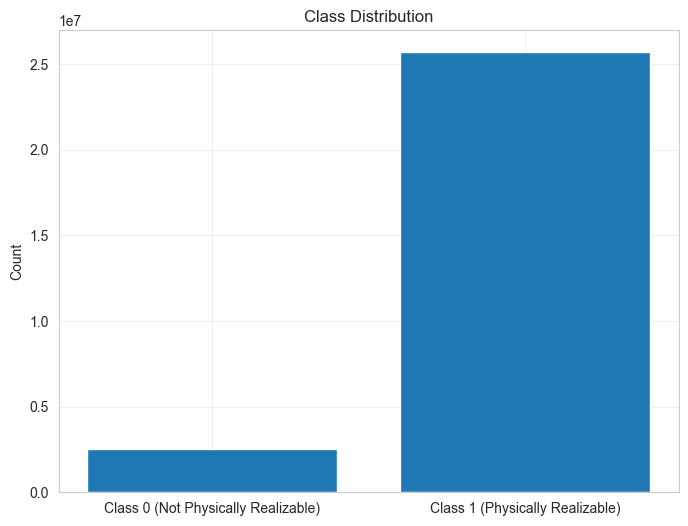

In [5]:
# Check class balance
unique_values, counts = np.unique(y_flat, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("Class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat) * 100:.2f}%)")

plt.figure(figsize=(8, 6))
plt.bar(['Class 0 (Not Physically Realizable)', 'Class 1 (Physically Realizable)'], 
        [class_distribution.get(0, 0), class_distribution.get(1, 0)])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Split Data for Training, Validation, and Testing

Overall class distribution:
Class 0.0: 2528586 (8.96%)
Class 1.0: 25700742 (91.04%)


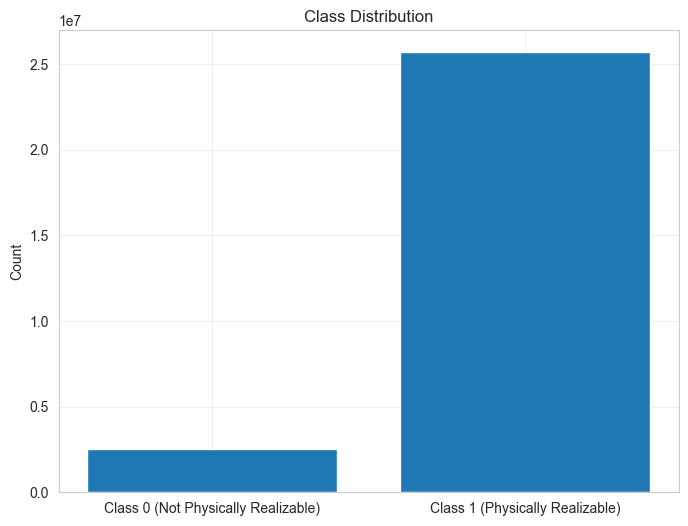

In [6]:
# Check class balance before splitting
unique_values, counts = np.unique(y_flat, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("Overall class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat) * 100:.2f}%)")

plt.figure(figsize=(8, 6))
plt.bar(['Class 0 (Not Physically Realizable)', 'Class 1 (Physically Realizable)'], 
        [class_distribution.get(0, 0), class_distribution.get(1, 0)])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
# Sample only 10% of the data to make training more manageable

In [8]:
# Subsample data (10% of total) with stratification to maintain class distribution
# We'll use stratified sampling to maintain the same class distribution

# Create mask for 0 and 1 classes
mask_0 = (y_flat == 0)
mask_1 = (y_flat == 1)

# Get indices for each class
indices_0 = np.where(mask_0)[0]
indices_1 = np.where(mask_1)[0]

# Select 10% from each class
sample_size_0 = len(indices_0) // 10
sample_size_1 = len(indices_1) // 10

# Randomly sample indices
np.random.seed(42)
sampled_indices_0 = np.random.choice(indices_0, size=sample_size_0, replace=False)
sampled_indices_1 = np.random.choice(indices_1, size=sample_size_1, replace=False)

# Combine indices
sampled_indices = np.concatenate([sampled_indices_0, sampled_indices_1])

# Shuffle the combined indices
np.random.shuffle(sampled_indices)

# Subset the data
X_flat_sampled = X_flat[sampled_indices]
y_flat_sampled = y_flat[sampled_indices]

print(f"Original data size: {len(X_flat):,} samples")
print(f"Sampled data size: {len(X_flat_sampled):,} samples ({len(X_flat_sampled)/len(X_flat)*100:.1f}% of original)")

# Check class distribution after sampling
unique_values, counts = np.unique(y_flat_sampled, return_counts=True)
class_distribution = dict(zip(unique_values, counts))

print("\nSampled data class distribution:")
for value, count in class_distribution.items():
    print(f"Class {value}: {count} ({count / len(y_flat_sampled) * 100:.2f}%)")

Original data size: 28,229,328 samples
Sampled data size: 2,822,932 samples (10.0% of original)

Sampled data class distribution:
Class 0.0: 252858 (8.96%)
Class 1.0: 2570074 (91.04%)


In [9]:
# Split the sampled data into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_flat_sampled, y_flat_sampled, test_size=0.2, random_state=42, stratify=y_flat_sampled
)

# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Check class distribution in each split
for name, y_data in [('Training', y_train), ('Validation', y_val), ('Testing', y_test)]:
    unique_values, counts = np.unique(y_data, return_counts=True)
    class_dist = dict(zip(unique_values, counts))
    print(f"\n{name} set class distribution:")
    for value, count in class_dist.items():
        print(f"Class {value}: {count} ({count / len(y_data) * 100:.2f}%)")


X_train shape: (1693758, 12), y_train shape: (1693758,)
X_val shape: (564587, 12), y_val shape: (564587,)
X_test shape: (564587, 12), y_test shape: (564587,)

Training set class distribution:
Class 0.0: 151714 (8.96%)
Class 1.0: 1542044 (91.04%)

Validation set class distribution:
Class 0.0: 50572 (8.96%)
Class 1.0: 514015 (91.04%)

Testing set class distribution:
Class 0.0: 50572 (8.96%)
Class 1.0: 514015 (91.04%)


## 6. Define U-Net Architecture for Semantic Segmentation

In [48]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)
    

In [49]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1):
        super(SimpleUNet, self).__init__()
        
        # Encoder - fewer layers to avoid size issues
        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        
        # Middle
        self.middle = ConvBlock(128, 256)
        
        # Decoder - fewer layers to avoid size issues
        self.dec2 = ConvBlock(256 + 128, 128)
        self.dec1 = ConvBlock(128 + 64, 64)
        
        # Final output
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)
        
        # Pooling and upsampling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        
    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        p1 = self.pool(enc1)
        
        enc2 = self.enc2(p1)
        p2 = self.pool(enc2)
        
        # Middle
        middle = self.middle(p2)
        
        # Decoder
        up2 = self.upsample(middle)
        # Ensure dimensions match
        if up2.size()[2:] != enc2.size()[2:]:
            up2 = F.interpolate(up2, size=enc2.size()[2:], mode='nearest')
        merge2 = torch.cat([enc2, up2], dim=1)
        dec2 = self.dec2(merge2)
        
        up1 = self.upsample(dec2)
        # Ensure dimensions match
        if up1.size()[2:] != enc1.size()[2:]:
            up1 = F.interpolate(up1, size=enc1.size()[2:], mode='nearest')
        merge1 = torch.cat([enc1, up1], dim=1)
        dec1 = self.dec1(merge1)
        
        # Final output
        out = self.final(dec1)
        return out 

## 7. Prepare Data Loaders for U-Net Training

In [50]:
# We'll train a U-Net model to predict the physical realizability mask (y) from the first 12 Mueller matrix elements (X).
# This is a binary classification problem at the pixel level, where we want to determine if the partial Mueller matrix
# information (first 12 elements) is sufficient to predict whether a pixel passes the physical realizability test.


In [51]:
# For U-Net, we reshape the data back to 2D images
def prepare_unet_data():
    # Reshape X back to (num_samples, height, width, num_features)
    # We need to first reshape our sampled data back to 2D structure
    
    # Calculate how many complete samples we can create from our sampled flat data
    # Each sample has height × width pixels
    pixels_per_sample = height * width
    num_complete_samples = len(X_flat_sampled) // pixels_per_sample
    
    # Take only enough data points to create complete samples
    usable_flat_size = num_complete_samples * pixels_per_sample
    X_usable = X_flat_sampled[:usable_flat_size]
    y_usable = y_flat_sampled[:usable_flat_size]
    
    # Reshape to (num_samples, height, width, num_features)
    X_reshaped = X_usable.reshape(num_complete_samples, height, width, -1)
    
    # Reshape y to (num_samples, height, width)
    y_reshaped = y_usable.reshape(num_complete_samples, height, width)
    
    print(f"Reshaped data for U-Net: {X_reshaped.shape} and {y_reshaped.shape}")
    
    # Split data by samples
    train_samples, test_samples = train_test_split(
        np.arange(X_reshaped.shape[0]), test_size=0.2, random_state=42
    )
    
    train_samples, val_samples = train_test_split(
        train_samples, test_size=0.25, random_state=42
    )
    
    # Extract the corresponding samples
    X_train = X_reshaped[train_samples]
    y_train = y_reshaped[train_samples]
    
    X_val = X_reshaped[val_samples]
    y_val = y_reshaped[val_samples]
    
    X_test = X_reshaped[test_samples]
    y_test = y_reshaped[test_samples]
    
    # Skip normalization as requested
    
    # Transpose from (samples, height, width, channels) to (samples, channels, height, width)
    # which is the format expected by PyTorch
    X_train_ready = np.transpose(X_train, (0, 3, 1, 2))
    X_val_ready = np.transpose(X_val, (0, 3, 1, 2))
    X_test_ready = np.transpose(X_test, (0, 3, 1, 2))
    
    # Expand dimensions for y to make it (samples, 1, height, width)
    y_train = np.expand_dims(y_train, axis=1)
    y_val = np.expand_dims(y_val, axis=1)
    y_test = np.expand_dims(y_test, axis=1)
    
    # Check class balance in train/val/test sets to ensure stratification worked
    for name, y_data in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
        positive_rate = np.mean(y_data)
        print(f"{name} set positive class rate: {positive_rate:.4f}")
    
    return X_train_ready, y_train, X_val_ready, y_val, X_test_ready, y_test

# Prepare data for U-Net

In [52]:
X_train_unet, y_train_unet, X_val_unet, y_val_unet, X_test_unet, y_test_unet = prepare_unet_data()

print(f"U-Net training data shapes:")
print(f"X_train_unet: {X_train_unet.shape}, y_train_unet: {y_train_unet.shape}")
print(f"X_val_unet: {X_val_unet.shape}, y_val_unet: {y_val_unet.shape}")
print(f"X_test_unet: {X_test_unet.shape}, y_test_unet: {y_test_unet.shape}")

# Create PyTorch datasets and data loaders
train_dataset = TensorDataset(
    torch.tensor(X_train_unet, dtype=torch.float32),
    torch.tensor(y_train_unet, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_unet, dtype=torch.float32),
    torch.tensor(y_val_unet, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_unet, dtype=torch.float32),
    torch.tensor(y_test_unet, dtype=torch.float32)
)

# Create data loaders
batch_size = 4  # Adjust based on available memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


Reshaped data for U-Net: (14, 388, 516, 12) and (14, 388, 516)
Train set positive class rate: 0.9102
Val set positive class rate: 0.9106
Test set positive class rate: 0.9109
U-Net training data shapes:
X_train_unet: (8, 12, 388, 516), y_train_unet: (8, 1, 388, 516)
X_val_unet: (3, 12, 388, 516), y_val_unet: (3, 1, 388, 516)
X_test_unet: (3, 12, 388, 516), y_test_unet: (3, 1, 388, 516)


## 8. Define Training Functions


In [53]:
# Function to train the model for one epoch
def train_epoch(model, loader, optimizer, epoch):
    model.train()
    epoch_loss = 0
    
    with tqdm(total=len(loader), desc=f"Epoch {epoch+1}") as pbar:
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target) # built-in, class-weighted
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.update(1)
            pbar.set_postfix(loss=loss.item())
    
    return epoch_loss / len(loader)


In [54]:
# Function to validate the model
def validate(model, loader):
    model.eval()
    val_loss = 0
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            
            # Calculate loss
            loss = criterion(output, target) # built-in, class-weighted
            val_loss += loss.item()
            
            # Store predictions and targets for metrics
            y_true.append(target.cpu().numpy())
            probs = torch.sigmoid(output)          # turn logits → prob
            y_pred.append((probs > 0.5).float().cpu().numpy())
    
    # Concatenate batches
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    
    # Calculate metrics
    accuracy = np.mean((y_pred > 0.5) == y_true)
    
    # Flatten arrays for sklearn metrics
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)
    
    precision = precision_score(y_true_flat, y_pred_flat > 0.5)
    recall = recall_score(y_true_flat, y_pred_flat > 0.5)
    f1 = f1_score(y_true_flat, y_pred_flat > 0.5)
    
    return val_loss / len(loader), accuracy, precision, recall, f1


## 9. Train the U-Net Model

In [55]:
# Create SimpleUNet model instance
model = SimpleUNet(in_channels=12, out_channels=1).to(device)

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set up learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5, verbose=True
)

# Create directory for model checkpoints
model_dir = file_paths.model_save_path
model_dir.mkdir(parents=True, exist_ok=True)

# Training parameters
num_epochs = 20  # Increased from 3
best_val_loss = float('inf')
early_stopping_patience = 10
early_stopping_counter = 0

# Lists to store training history
train_losses = []
val_losses = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

/Users/chaechae/Desktop/EP_Code/pr_prediction/.venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [56]:
# Create SimpleUNet model instance
model = SimpleUNet(in_channels=12, out_channels=1).to(device)

# ---------- NEW BLOCK (just below ^) --------------------------
# Compute pixel-level class ratio on the TRAINING set
pos_fraction = y_train_unet.mean()          # ≈ 0.91 in your data
neg_fraction = 1.0 - pos_fraction
pos_weight_val = neg_fraction / pos_fraction

pos_weight = torch.tensor([pos_weight_val], device=device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Using BCEWithLogitsLoss with pos_weight = {pos_weight_val:.2f}")
# --------------------------------------------------------------

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using BCEWithLogitsLoss with pos_weight = 0.10


In [57]:
# Training loop
for epoch in range(num_epochs):
    start_time = time.time()
    
    # Train for one epoch
    train_loss = train_epoch(model, train_loader, optimizer, epoch)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, accuracy, precision, recall, f1 = validate(model, val_loader)
    val_losses.append(val_loss)
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Print epoch results
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} - Time: {epoch_time:.2f}s - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f} - Precision: {precision:.4f} - Recall: {recall:.4f} - F1: {f1:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_dir / 'best_simple_unet_model.pth')
        print(f"Saved best model with validation loss: {val_loss:.4f}")
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
    
    # Early stopping
    if early_stopping_counter >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

Epoch 1:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/20 - Time: 13.06s - Train Loss: 0.1079 - Val Loss: 0.1239
Accuracy: 0.0894 - Precision: 0.0000 - Recall: 0.0000 - F1: 0.0000
Saved best model with validation loss: 0.1239


/Users/chaechae/Desktop/EP_Code/pr_prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 2/20 - Time: 10.50s - Train Loss: 0.0762 - Val Loss: 0.1233
Accuracy: 0.0894 - Precision: 0.0000 - Recall: 0.0000 - F1: 0.0000
Saved best model with validation loss: 0.1233


...

Epoch 14/20 - Time: 10.71s - Train Loss: 0.0445 - Val Loss: 0.1477
Accuracy: 0.9106 - Precision: 0.9106 - Recall: 1.0000 - F1: 0.9532


Epoch 15:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 15/20 - Time: 10.79s - Train Loss: 0.0434 - Val Loss: 0.1494
Accuracy: 0.9107 - Precision: 0.9107 - Recall: 1.0000 - F1: 0.9532


Epoch 16:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 16/20 - Time: 10.43s - Train Loss: 0.0423 - Val Loss: 0.1469
Accuracy: 0.9108 - Precision: 0.9108 - Recall: 1.0000 - F1: 0.9533
Early stopping triggered after 16 epochs


# LightGBM classifier

In [58]:
# %% md
## 5  Per-pixel classification with an MLP
# We now build a feed-forward network that takes the 12 partial Mueller-matrix
# elements of a *single pixel* and predicts the boolean “physically realizable”
# label.  This lives completely separate from the U-Net segmentation branch.

# %% 5.0 Data loaders ---------------------------------------------------------
# wrap flat numpy arrays in TensorDataset
train_dataset_cls = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32),
)
val_dataset_cls = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32),
)
test_dataset_cls = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32),
)

# large batches are fine for tabular data
batch_size_cls   = 8_192
train_loader_cls = DataLoader(train_dataset_cls, batch_size=batch_size_cls, shuffle=True)
val_loader_cls   = DataLoader(val_dataset_cls,   batch_size=batch_size_cls)
test_loader_cls  = DataLoader(test_dataset_cls,  batch_size=batch_size_cls)

# %% 5.1 MLP architecture -----------------------------------------------------
class PixelMLP(nn.Module):
    def __init__(self, in_features: int = 12, hidden_sizes=(128, 64, 32)):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))   # single-logit output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)                 # raw logits (no sigmoid!)

clf_model = PixelMLP().to(device)

# %% 5.2 Loss, optimiser, scheduler ------------------------------------------
# positives ≈ 91 %  → weight minority 0-class higher
pos_fraction_cls = y_train.mean()
neg_fraction_cls = 1.0 - pos_fraction_cls
pos_weight_val   = neg_fraction_cls / pos_fraction_cls
criterion_cls    = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_val], device=device)
)
print(f"MLP pos_weight = {pos_weight_val:.2f}")

optimizer_cls = optim.Adam(clf_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_cls = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls, mode="min", factor=0.1, patience=3, verbose=True
)

# %% 5.3 Training / validation helpers ---------------------------------------
def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.set_grad_enabled(train):
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            if train:
                optimizer_cls.zero_grad()

            logits = model(data)
            loss   = criterion_cls(logits, target)

            if train:
                loss.backward()
                optimizer_cls.step()

            total_loss += loss.item() * data.size(0)

            probs = torch.sigmoid(logits)
            y_true.append(target.cpu().numpy())
            y_pred.append((probs > 0.5).float().cpu().numpy())

    y_true = np.concatenate(y_true).ravel()
    y_pred = np.concatenate(y_pred).ravel()

    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    return avg_loss, acc, prec, rec, f1

# %% 5.4 Train the MLP --------------------------------------------------------
best_val = float("inf")
epochs_cls = 15
for epoch in range(1, epochs_cls + 1):
    tr_loss, tr_acc, _, _, _ = run_epoch(clf_model, train_loader_cls, train=True)
    vl_loss, vl_acc, vl_prec, vl_rec, vl_f1 = run_epoch(clf_model, val_loader_cls, train=False)
    scheduler_cls.step(vl_loss)

    print(f"[MLP Epoch {epoch:02d}/{epochs_cls}] "
          f"train loss {tr_loss:.4f} • val loss {vl_loss:.4f} "
          f"• val F1 {vl_f1:.4f}")

    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(clf_model.state_dict(), file_paths.model_save_path / "best_pixel_mlp.pth")

# %% 5.5 Test-set performance -------------------------------------------------
clf_model.load_state_dict(torch.load(file_paths.model_save_path / "best_pixel_mlp.pth"))
ts_loss, ts_acc, ts_prec, ts_rec, ts_f1 = run_epoch(clf_model, test_loader_cls, train=False)
print(f"\nMLP TEST — loss {ts_loss:.4f}, acc {ts_acc:.4f}, "
      f"precision {ts_prec:.4f}, recall {ts_rec:.4f}, F1 {ts_f1:.4f}")

MLP pos_weight = 0.10


/Users/chaechae/Desktop/EP_Code/pr_prediction/.venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[MLP Epoch 01/15] train loss 0.0468 • val loss 0.0254 • val F1 0.9566
[MLP Epoch 02/15] train loss 0.0255 • val loss 0.0187 • val F1 0.9658
[MLP Epoch 03/15] train loss 0.0220 • val loss 0.0171 • val F1 0.9690
[MLP Epoch 04/15] train loss 0.0204 • val loss 0.0162 • val F1 0.9743
[MLP Epoch 05/15] train loss 0.0193 • val loss 0.0163 • val F1 0.9767
[MLP Epoch 06/15] train loss 0.0186 • val loss 0.0162 • val F1 0.9775
[MLP Epoch 07/15] train loss 0.0181 • val loss 0.0158 • val F1 0.9764
[MLP Epoch 08/15] train loss 0.0177 • val loss 0.0156 • val F1 0.9753
[MLP Epoch 09/15] train loss 0.0175 • val loss 0.0155 • val F1 0.9758
[MLP Epoch 10/15] train loss 0.0172 • val loss 0.0154 • val F1 0.9760
[MLP Epoch 11/15] train loss 0.0171 • val loss 0.0154 • val F1 0.9742
[MLP Epoch 12/15] train loss 0.0170 • val loss 0.0154 • val F1 0.9751
[MLP Epoch 13/15] train loss 0.0168 • val loss 0.0153 • val F1 0.9766
[MLP Epoch 14/15] train loss 0.0167 • val loss 0.0153 • val F1 0.9752
[MLP Epoch 15/15] tr

# Xgboost

In [59]:
# %% md
### 5-bis  LightGBM Gradient-Boosted Trees

import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train, weight=np.where(y_train == 0, pos_weight_val, 1.0))
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = dict(
    objective   = "binary:logistic",
    eval_metric = "logloss",
    eta         = 0.05,
    max_depth   = 7,
    subsample   = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight_val,   # handles imbalance
    nthread     = -1,
    seed        = 42,
)

print("🔧  Training XGBoost …")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round      = 1000,
    evals                = [(dval, "val")],
    early_stopping_rounds= 50,
    verbose_eval         = 100,
)

print("\n🧪  XGBoost test metrics")
y_hat = (bst.predict(dtest) > 0.5).astype(int)
print(f"accuracy  {accuracy_score(y_test, y_hat):.4f}")
print(f"precision {precision_score(y_test, y_hat):.4f}")
print(f"recall    {recall_score(y_test, y_hat):.4f}")
print(f"F1        {f1_score(y_test, y_hat):.4f}")

# save + reload
bst.save_model(str(file_paths.model_save_path / "pixel_xgb.json"))
# later:  xgb.Booster().load_model("pixel_xgb.json")

🔧  Training XGBoost …
[0]	val-logloss:0.30229
[100]	val-logloss:0.06030
[200]	val-logloss:0.05496
[300]	val-logloss:0.05360
[400]	val-logloss:0.05298
[500]	val-logloss:0.05265
[600]	val-logloss:0.05247
[700]	val-logloss:0.05238
[800]	val-logloss:0.05234
[847]	val-logloss:0.05234

🧪  XGBoost test metrics
accuracy  0.9778
precision 0.9860
recall    0.9896
F1        0.9878


# CatBoostClassifier

In [60]:
!pip install pytorch-tabnet -q    # ← run once if not installed

In [61]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train, weight=np.where(y_train == 0, pos_weight_val, 1.0))
val_pool   = Pool(X_val,   y_val)

cat = CatBoostClassifier(
    loss_function       = "Logloss",
    depth               = 8,
    learning_rate       = 0.05,
    iterations          = 2000,
    l2_leaf_reg         = 3.0,
    random_seed         = 42,
    eval_metric         = "Logloss",
    verbose             = 200,
    early_stopping_rounds = 100,
    class_weights       = [pos_weight_val, 1.0],   # index 0 → class 0
)

print("🔧  Training CatBoost …")
cat.fit(train_pool, eval_set=val_pool)

print("\n🧪  CatBoost test metrics")
y_hat = (cat.predict_proba(X_test)[:, 1] > 0.5).astype(int)
print(f"accuracy  {accuracy_score(y_test, y_hat):.4f}")
print(f"precision {precision_score(y_test, y_hat):.4f}")
print(f"recall    {recall_score(y_test, y_hat):.4f}")
print(f"F1        {f1_score(y_test, y_hat):.4f}")

# save + reload
cat.save_model(file_paths.model_save_path / "pixel_catboost.cbm")

🔧  Training CatBoost …
0:	learn: 0.5330408	test: 0.5358035	best: 0.5358035 (0)	total: 43.9ms	remaining: 1m 27s
200:	learn: 0.0029217	test: 0.0240922	best: 0.0240922 (197)	total: 7.34s	remaining: 1m 5s
400:	learn: 0.0029010	test: 0.0239119	best: 0.0239119 (320)	total: 14.9s	remaining: 59.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.02391186397
bestIteration = 320

Shrink model to first 321 iterations.

🧪  CatBoost test metrics
accuracy  0.9420
precision 0.9401
recall    1.0000
F1        0.9691
